# (25) blog: KL

**Motivation**: <br>

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-vae/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-vae/figs')
tmp_dir = os.path.join(git_dir, 'jb-vae/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, 'PoissonVAE'))
from analysis.eval import sparse_score
from figures.fighelper import *
from main.train_vae import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
fig_dir = pjoin(fig_base_dir, 'blog')
os.makedirs(fig_dir, exist_ok=True)

print(sorted(os.listdir(fig_dir)))

['surprise.png']

In [3]:
kws_fig = {
    'transparent': True,
    'bbox_inches': 'tight',
    'dpi': 900,
}
print(kws_fig)

{'transparent': True, 'bbox_inches': 'tight', 'dpi': 900}

## Hypothesis testing

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [5]:
def plot_heatmap(add_labels=False, display=True):
    # error threshold
    alpha = -np.log2(0.05)  # ~ 4.322
    
    kl_values = np.linspace(0, 10, 1000)
    n_values = np.arange(0, 101)
    
    # grid
    kl_grid, n_grid = np.meshgrid(
        kl_values, n_values)
    # surprisal := -log_2(P) = N * KL
    surprisal = n_grid * kl_grid

    y_size = 4.8 if add_labels else 4.6
    fig, axes = plt.subplots(
        nrows=1,
        ncols=3,
        figsize=(10.2, y_size),
        layout='constrained',
        width_ratios=[1, 1, 0.04],
    )
    
    heatmap = axes[0].pcolormesh(
        kl_grid, n_grid, surprisal,
        shading='auto', 
        cmap='viridis',
    )
    cs = axes[0].contour(
        kl_grid, n_grid, surprisal,
        levels=[alpha],
        colors='white',
        linestyles='--',
        linewidths=2,
    )
    cbar = plt.colorbar(heatmap, cax=axes[2])
    # axes[2].axhline(y=alpha, color='white', linestyle='--', linewidth=1)
    
    # 2. log scale
    kl_values = np.logspace(-1, 1, 1000)
    kl_grid, n_grid = np.meshgrid(
        kl_values, n_values)
    surprisal = n_grid * kl_grid
    
    heatmap = axes[1].pcolormesh(
        kl_grid, n_grid, surprisal,
        shading='auto', 
        cmap='viridis',
    )
    cs = axes[1].contour(
        kl_grid, n_grid, surprisal,
        levels=[alpha],
        colors='white',
        linestyles='--',
        linewidths=2,
    )
    axes[1].set(xscale='log', yscale='log', ylim=(1, 100))
    
    
    # add annotation: Surprisal
    text = r'$Surprisal > -\log_2(0.05) \approx 4.322$'
    for i in range(2):
        axes[i].annotate(
            text=text,
            fontsize=10.0 if i == 0 else 16.0,
            xy=(0.06, 0.06) if i == 0 else (0.24, 0.27),
            xycoords='axes fraction',
            color='white',
            rotation=-45,
        )
    
    # add annotation: P
    
    text = r'$P < 0.05$'
    for i in range(2):
        axes[i].annotate(
            text=text,
            fontsize=9.0 if i == 0 else 13.0,
            xy=(0.04, 0.08) if i == 0 else (0.37, 0.37),
            xycoords='axes fraction',
            color='white',
            rotation=-45,
        )
    
    text = r'$P > 0.05$'
    for i in range(2):
        axes[i].annotate(
            text=text,
            fontsize=9.0 if i == 0 else 13.0,
            xy=(-0.01, 0.001) if i == 0 else (0.30, 0.30),
            xycoords='axes fraction',
            color='white',
            rotation=-45,
        )

    if add_labels:
        text = r'$Surprisal :\!\!\!= \log_2(P) = N * KL(p_\text{world} \vert\vert p_\text{brain})$'
        fig.suptitle(text, y=1.1)
        axes[0].set_xlabel('KL (bits)')
        axes[1].set_xlabel('KL (bits, log scale)')
        axes[0].set_ylabel('Number of samples (N)')
        cbar.set_label('Surprisal (bits)')

    if display:
        plt.show()
    else:
        plt.close()

    return fig, axes

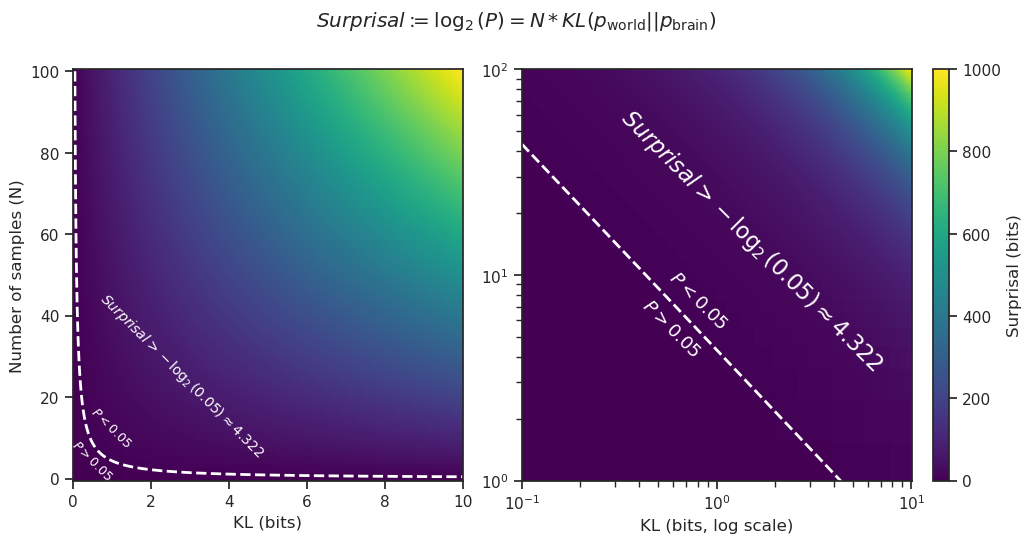

In [6]:
fig, axes = plot_heatmap(add_labels=True)

### Save the fig

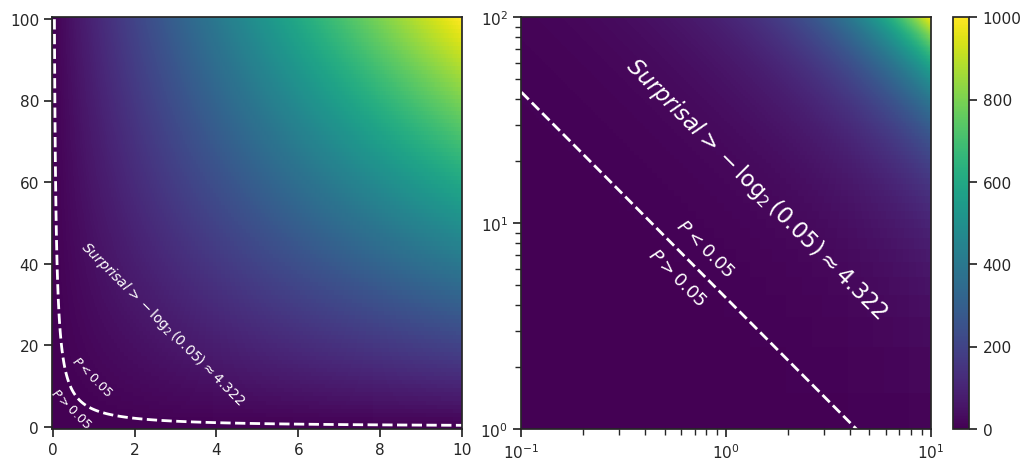

In [7]:
fig, axes = plot_heatmap(False, True)
# fig.savefig(pjoin(fig_dir, 'surprise.pdf'), **kws_fig)
fig.savefig(pjoin(fig_dir, 'surprise.png'), **kws_fig)

## Belief updating

In [56]:
def plot_belief_updates(display=True):
    p_world = [0, 0, 0, 0, 0, 0, 0, 1]
    q_dict = {
        '0': [1/8, 1/8, 1/8, 1/8, 1/8, 1/8, 1/8, 1/8],
        '1': [0, 0, 0, 0, 1/4, 1/4, 1/4, 1/4],
        '2': [0, 0, 0, 0, 0, 0, 1/2, 1/2],
        '3': [0, 0, 0, 0, 0, 0, 0, 1],
    }
    width = 0.8
    xs = np.arange(1, 9)
    
    
    fig, axes = plt.subplots(
        nrows=1,
        ncols=4,
        sharey='row',
        figsize=(10.2, 2.45),
        layout='constrained',
    )
    axes[0].set_yticks(np.linspace(0, 1, 9))
    
    for i in range(4):
        ax = axes[i]
        ax.bar(
            x=xs,
            height=p_world,
            width=width,
            label=r'$p_\text{word}$',
            color='dimgrey',
            edgecolor='k',
            alpha=0.8,
        )
        ax.bar(
            x=xs,
            height=q_dict[str(i)],
            width=width,
            label=r'$p_\text{brain}$',
            color='#29ABE2',
            edgecolor='royalblue',
            alpha=0.8,
        )
        ax.set_xticks(x)
        ax.legend()
        ax.grid(axis='y')

    if display:
        plt.show()
    else:
        plt.close()
    return fig, axes

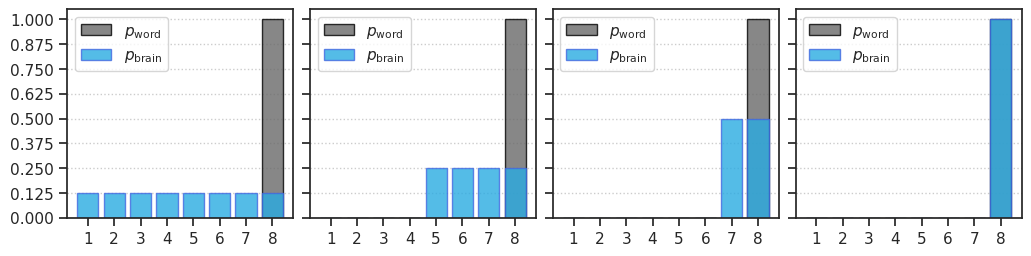

In [58]:
fig, axes = plot_belief_updates()
fig.savefig(pjoin(fig_dir, 'belief_updates.pdf'), **kws_fig)

## Stirling formula

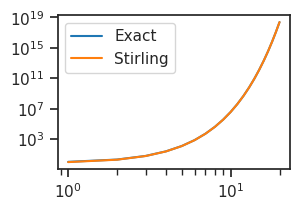

In [2]:
import math

n = range(1,21)
exact = [math.factorial(i) for i in n]
stirl = [math.sqrt(2*math.pi*i)*(i/math.e)**i for i in n]

plt.loglog(n, exact, label='Exact')
plt.loglog(n, stirl, label='Stirling')
plt.legend()
plt.show()

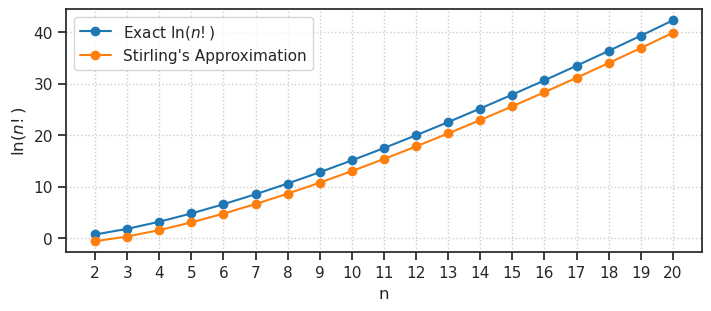

In [3]:
n = np.arange(2, 21)
exact = np.log([np.math.factorial(i) for i in n])
# stirl_approx = n * np.log(n) - n + 0.5 * np.log(2 * np.pi * n)
stirl_approx = n * np.log(n) - n

fig, ax = create_figure(1, 1, figsize=(7, 3))
ax.plot(n, exact, marker='o', label='Exact $\ln(n!)$')
ax.plot(n, stirl_approx, marker='o', label="Stirling's Approximation")
ax.locator_params(axis='x', nbins=30)
ax.set_xlabel('n')
ax.set_ylabel('$\ln(n!)$')
ax.legend()
ax.grid()
plt.show()